In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "8"

import numpy as np
from operators import operator,operator_loss,state,state_loss,gkp_squeezing

import scipy.optimize as so
import matplotlib.pyplot as plt


In [2]:
def minimize(objective, x0, bounds):
    result = so.minimize(objective, x0, method = 'L-BFGS-B', bounds = bounds)
    return result.fun,result.x

def minimize_multistart(objective, bounds, nstart=300):
    best_fun = np.inf
    best_x = None

    for _ in range(nstart):
        x0 = np.array([np.random.uniform(low, high) for low, high in bounds])
        res = so.minimize(objective,x0,method='L-BFGS-B', bounds=bounds)
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    return best_fun, best_x

def objective_optimized_operator (dim,fq,fp,eta):
    def objective (x):
        return float(np.real_if_close(gkp_squeezing(operator_loss(dim,fq,fp,eta),state(dim,x[0],x[1]))))
    return objective

In [ ]:
Nspace = np.array([7,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,150])
np.save('results/nonsym/Nspace.npy',Nspace)
eta = np.arange(0.75,1.01,0.01) 
np.save('results/nonsym/eta.npy',eta)

In [ ]:
DEF_FQ_MIN = 0.25
DEF_FQ_MAX = 1.4

DEF_FP_MIN = 0.25
DEF_FP_MAX = 2.5

Nspace = np.load('results/nonsym/Nspace.npy')
eta = np.load('results/nonsym/eta.npy')

fq = np.sqrt(np.pi)/2
fp = np.sqrt(np.pi)

    
for dim in Nspace:
    ksi_list = []
    coef_k1_list = []
    coef_k2_list = []
    for x in eta:
        opt_ksi,opt_coef = minimize_multistart(objective_optimized_operator(dim,fq,fp,x),[(DEF_FQ_MIN, DEF_FQ_MAX),(DEF_FP_MIN,DEF_FP_MAX)])
        ksi_list.append(opt_ksi)
        coef_k1_list.append(opt_coef[0])
        coef_k2_list.append(opt_coef[1])
    np.save(f'results/nonsym/gkp_sq_opt_{dim}.npy', ksi_list)
    np.save(f'results/nonsym/coef_opt_k1_{dim}.npy', coef_k1_list)
    np.save(f'results/nonsym/coef_opt_k2_{dim}.npy', coef_k2_list)

In [ ]:
Nspace = np.load('results/nonsym/Nspace.npy')
eta = np.load('results/nonsym/eta.npy')
fq = np.sqrt(np.pi)/2
fp = np.sqrt(np.pi)

for dim in Nspace:
    ksi_list = []
    rho = state(dim,fq,fp)
    for x in eta:
        op = operator_loss(dim,fq,fp,x)
        ksi = gkp_squeezing(rho,op)
        ksi_list.append(ksi)
    np.save('results/nonsym/gkp_sq_lossy_{dim}.npy', ksi_list)
    

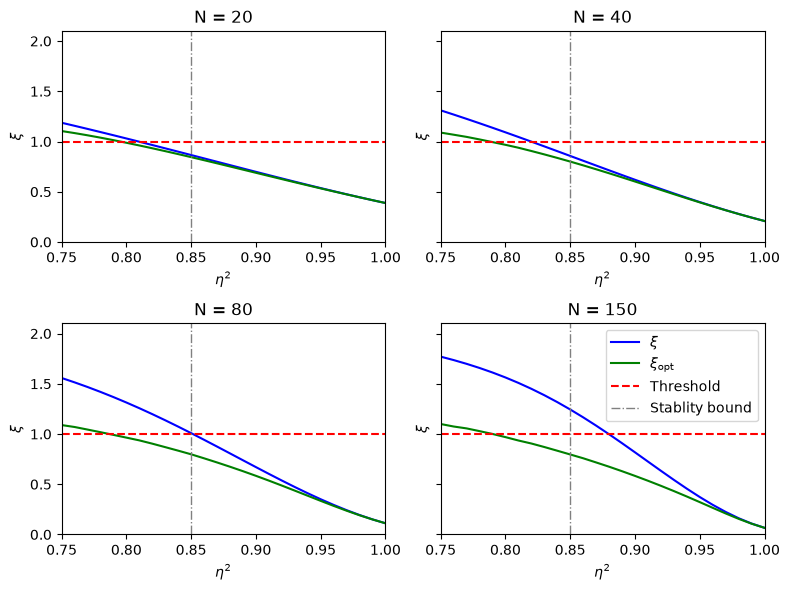

In [24]:
Nspace = np.array([20,40,80,150])
eta = np.load(r'results/nonsym/eta.npy')
fq = np.sqrt(np.pi)/2
fp = np.sqrt(np.pi)


def load_dataset (dim):
    load1 = np.load(f'results/nonsym/gkp_sq_lossy_{dim}.npy')
    load2 = np.load(f'results/nonsym/gkp_sq_opt_{dim}.npy')
    return load1,load2


fig0, ax0 = plt.subplots(2,2,figsize=(8,6),sharey = True )
for i,dim in enumerate(Nspace):
    row = i // 2
    col = i  % 2
    ksi1,ksi2 = load_dataset(dim)
    ax0[row,col].plot(eta,ksi1,label = r'$\xi$', color = 'blue')
    ax0[row,col].plot(eta,ksi2,label = r'$\xi_{\text{opt}}$',color = 'green')
    ax0[row,col].axhline(y = 1, label = 'Threshold',color="red", linestyle = '--')
    ax0[row,col].set(xlabel = r'$\eta^2$',ylabel=r'$\xi$',title = fr'N = {dim}')
    ax0[row,col].set_xlim(0.75,1.0)
    ax0[row,col].set_ylim(0.0,2.1)

    ax0[row,col].axvline(x = 0.85, label = 'Stablity bound',color="gray", linestyle = '-.', linewidth = 1)


ax0[1,1].legend()
plt.tight_layout()
plt.show()
fig0.savefig("results/figs/optimized_nonsym.svg")


[np.complex128(4.066437147560663+6.334347587072906e-32j), np.complex128(0.5305038503601054-3.4423456094998385e-31j), np.complex128(1.0326715349418407-3.4644693233165226e-31j), np.complex128(2.428259243725364-6.947312646272329e-31j), np.complex128(2.7524592964095973-1.2445681483723864e-30j), np.complex128(4.6132848305777685+6.998286183516156e-31j), np.complex128(5.572346655002548+1.287107517295011e-30j), np.complex128(6.540810857254996+9.246861776493222e-31j), np.complex128(10.756627186333631+3.8409770234908387e-31j), np.complex128(11.23608083070333-2.1857528927271673e-30j), np.complex128(12.509430964335024+2.403311328059247e-31j), np.complex128(14.073476279591588+2.569072599903468e-30j), np.complex128(15.865091984324707-6.840036680682191e-32j), np.complex128(18.381030721783617+9.006631152120299e-31j), np.complex128(18.22319245030623-1.7754523778648502e-31j), np.complex128(20.883784627248957-6.64622448139709e-31j), np.complex128(35.981696038714446-1.5855212397606898e-30j)]


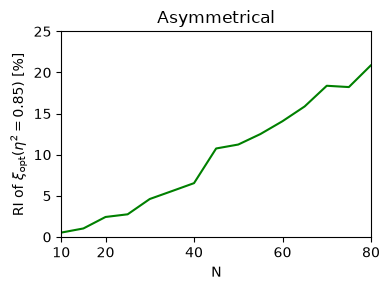

In [15]:
#improvement at the threshold 
Nspace = np.load('results/nonsym/Nspace.npy')
eta = np.load('results/nonsym/eta.npy')

def load_dataset (dim):
    load1 = np.load(f'results/nonsym/gkp_sq_lossy_{dim}.npy')
    load2 = np.load(f'results/nonsym/gkp_sq_opt_{dim}.npy')
    return load1,load2


improvement = []
for i,dim in enumerate(Nspace):
    load1,load2 = load_dataset(dim)
    value1 = load1[10]
    value2 = load2[10]
    diff = 100- value2/value1*100 
    improvement.append(diff)
print(improvement)
fig0, ax0 = plt.subplots(figsize=(4,3),sharey = True )
ax0.plot(Nspace,improvement,color = 'green')
ax0.set(xlabel = r'N',ylabel=r'RI of $\xi_{\mathrm{opt}}(\eta^2 = 0.85)$ [%]',title = fr'Asymmetrical')
ax0.set_xlim(10,80)
ax0.set_ylim(0,25)
ax0.set_xticks([10, 20, 40, 60, 80])

plt.tight_layout()
plt.show()
fig0.savefig("results/figs/improvement-nonsym.svg")

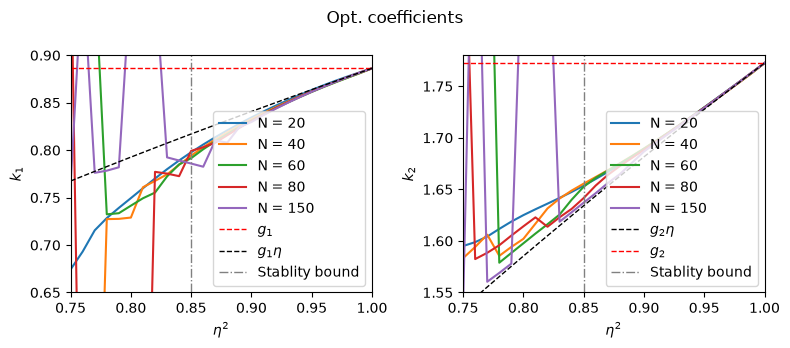

In [23]:
Nspace = np.array([20,40,60,80,150])
eta = np.load(f'results/nonsym/eta.npy')

def load_dataset (dim):
    load1 = np.load(f'results/nonsym/coef_opt_k1_{dim}.npy')
    load2 = np.load(f'results/nonsym/coef_opt_k2_{dim}.npy')
    return load1,load2

fq_format = "{:.2f}".format(fq)
fp_format = "{:.2f}".format(fp)

fig0, ax0 = plt.subplots(1,2,figsize=(8,3.5))
for i,dim in enumerate(Nspace):
    coef1,coef2 = load_dataset(dim)
    ax0[0].plot(eta,coef1, label = f'N = {dim}')
    ax0[1].plot(eta,coef2, label = f'N = {dim}')

ax0[0].axhline(y = np.sqrt(np.pi)/2, label = r'$g_1$',color="red", linestyle = '--',linewidth = 1)
ax0[0].plot(eta,f1,color = 'black', label= r'$g_1 \eta$',linestyle = '--',linewidth = 1)
ax0[1].plot(eta,f2,color = 'black', label= r'$g_2 \eta$',linestyle = '--',linewidth = 1)
ax0[1].axhline(y = np.sqrt(np.pi), label = r'$g_2$',color="red", linestyle = '--',linewidth = 1)
ax0[0].axvline(x = 0.85,color="gray", linestyle = '-.',linewidth = 1,label = 'Stablity bound')
ax0[1].axvline(x = 0.85,color="gray", linestyle = '-.',linewidth = 1,label = 'Stablity bound')

ax0[0].set(xlabel = r'$\eta^2$',ylabel=r'$k_1$',title = fr'')
ax0[1].set(xlabel = r'$\eta^2$',ylabel=r'$k_2$',title = fr'')

ax0[0].set_xlim(0.75,1.0)
ax0[1].set_xlim(0.75,1.0)
ax0[0].set_ylim(0.65,0.9)
ax0[1].set_ylim(1.55,1.78)
f1 = fq*np.sqrt(eta)
f2 = fp*np.sqrt(eta)



ax0[0].legend()
ax0[1].legend()
fig0.suptitle('Opt. coefficients')

plt.tight_layout()
plt.show()
fig0.savefig("results/figs/optimized_coef_nonsym.svg")
